# 6. Review Behavior Archetypes (K-Means)

Cluster name-grouped review profiles into behavioral archetypes. Identifies recurring patterns in rating behavior across the review pool.

**Important caveat:** Google Play does not expose stable user IDs. Common Hebrew names (Yossi Cohen, Haim Cohen, etc.) likely conflate multiple distinct people sharing a real name. This analysis treats groups of reviews under the same username as the unit of analysis. The clusters describe behavioral patterns in the review pool, not personas of identifiable individual users. User-level conclusions should not be drawn from this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
sns.set_style('whitegrid')

import sqlite3
from pathlib import Path

# SQLite connection. The repo ships with the populated DB.
DB_PATH = Path("..") / "data" / "processed" / "reviews.db"
engine = sqlite3.connect(DB_PATH)

# Load name-groups with sentiment data (others lack feature values)
groups = pd.read_sql("""
SELECT * FROM user_features
WHERE positive_ratio IS NOT NULL
  AND negative_ratio IS NOT NULL
""", engine)

print(f"Name-groups with sentiment data: {len(groups):,}")

Name-groups with sentiment data: 1,963


### Evidence: name-groups conflate distinct people

The query below pulls the 10 most active name-groups (after excluding the `משתמש Google` default). It reports how many reviews each name produced, how many distinct apps it spans, and over how many years. A single person reviewing five or more banking apps over many years is implausible. A common Hebrew name (e.g., Yossi Cohen) shared by many distinct individuals is the parsimonious explanation.

In [2]:
# Detect the name column in user_features (varies by build)
name_col = next((c for c in groups.columns
                 if c.lower() in ('user_name', 'name', 'username')),
                None)
if name_col is None:
    raise ValueError(f"No name column found. Columns: {list(groups.columns)}")

# Top 10 name-groups by review count, after excluding Google default
mask = ~groups[name_col].astype(str).str.contains('משתמש Google', na=False)
evidence = (groups[mask]
            .nlargest(10, 'total_reviews')
            [[name_col, 'total_reviews', 'apps_reviewed', 'lifespan_days']]
            .copy())
evidence['years_span'] = (evidence['lifespan_days'] / 365.0).round(1)
evidence = evidence.drop(columns='lifespan_days').rename(columns={
    name_col: 'name',
    'total_reviews': 'reviews',
    'apps_reviewed': 'apps'
}).reset_index(drop=True)
evidence

,name,reviews,apps,years_span
0,יוסי כהן,14,7,5.4
1,חיים כהן,12,6,4.7
2,דוד כהן,11,5,5.1
3,יעקב כהן,11,7,5.8
4,משה דובק,11,3,4.6
5,אלי כהן,10,5,4.7
6,יצחק כהן,10,6,5.1
7,מיכל כהן,10,5,5.5
8,משה כהן,10,6,4.9
9,דוד,8,6,3.1


## 6.1 Feature Setup

Ten aggregate features computed per name-group:

- `total_reviews`, `apps_reviewed`, `lifespan_days`, `reviews_per_month`
- `avg_score`, `std_score`, `avg_review_length`
- `positive_ratio`, `negative_ratio`, `developer_response_rate`

Standardized before clustering since features have different scales.

In [3]:
FEATURES = [
    'total_reviews', 'apps_reviewed', 'avg_score', 'std_score',
    'avg_review_length', 'lifespan_days', 'reviews_per_month',
    'positive_ratio', 'negative_ratio', 'developer_response_rate'
]

X_raw = groups[FEATURES].fillna(groups[FEATURES].mean())
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print(f"Feature matrix: {X.shape}")
X_raw.describe().round(2)

Feature matrix: (1963, 10)


,total_reviews,apps_reviewed,avg_score,std_score,avg_review_length,lifespan_days,reviews_per_month,positive_ratio,negative_ratio,developer_response_rate
count,1963.00,1963.00,1963.00,1963.00,1963.00,1963.00,1963.00,1963.00,1963.00,1963.00
mean,2.34,2.19,3.66,0.87,58.53,631.17,1.01,0.55,0.32,0.61
std,0.94,0.70,1.40,1.09,65.23,547.35,4.87,0.39,0.36,0.32
min,2.00,1.00,1.00,0.00,3.00,0.00,0.03,0.00,0.00,0.00
25%,2.00,2.00,3.00,0.00,18.00,161.00,0.07,0.00,0.00,0.50
50%,2.00,2.00,4.00,0.00,38.50,495.00,0.14,0.50,0.20,0.50
75%,2.00,2.00,5.00,2.00,74.58,984.50,0.39,1.00,0.50,1.00
max,14.00,7.00,5.00,2.83,863.00,2114.00,90.00,1.00,1.00,1.00


## 6.2 Determine Number of Clusters

Two metrics for k selection:

- **Elbow**: lower inertia is better, but flattens after the right k.
- **Silhouette**: higher means tighter, more separated clusters.

Test k = 2 to 10.

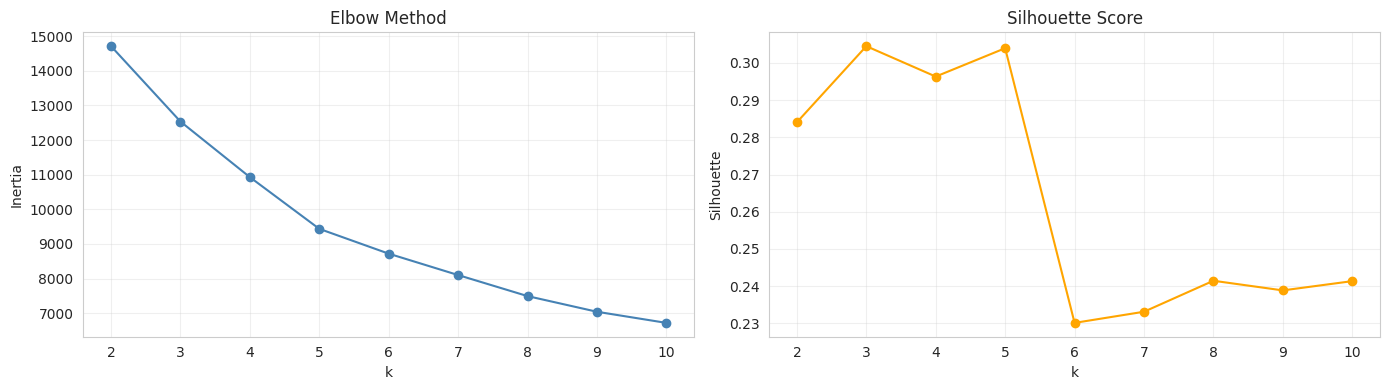

Best k by silhouette: 3


In [4]:
RANDOM_STATE = 42

ks = list(range(2, 11))
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ks, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ks, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print(f"Best k by silhouette: {best_k}")

## 6.3 Fit K-Means and Profile Clusters

Select k=3 (highest silhouette, elbow plateaus there). After fitting, identify each cluster by its most distinguishing feature and assign descriptive archetype labels.

In [5]:
K = 3
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
groups['cluster'] = km.fit_predict(X)

# Identify clusters by their most distinguishing feature
profile_means = groups.groupby('cluster')[FEATURES].mean()

cross_app_cluster = profile_means['apps_reviewed'].idxmax()
remaining = profile_means.drop(cross_app_cluster)
angry_cluster = remaining['avg_score'].idxmin()
happy_cluster = remaining.drop(angry_cluster).index[0]

archetype_map = {
    cross_app_cluster: 'Cross-App Reviewers',
    angry_cluster: 'Angry Detailed',
    happy_cluster: 'Happy Brief',
}
groups['archetype'] = groups['cluster'].map(archetype_map)

# Profile by archetype
profile = groups.groupby('archetype')[FEATURES].mean()
profile['size'] = groups['archetype'].value_counts()
profile['size_pct'] = (profile['size'] / len(groups) * 100).round(1)

profile.T.round(2)

archetype,Angry Detailed,Cross-App Reviewers,Happy Brief
total_reviews,2.18,5.37,2.15
apps_reviewed,2.08,4.32,2.06
avg_score,2.49,3.58,4.85
std_score,1.53,1.26,0.17
avg_review_length,85.93,66.54,29.94
lifespan_days,632.04,1287.94,557.15
reviews_per_month,1.20,0.19,0.91
positive_ratio,0.25,0.53,0.86
negative_ratio,0.61,0.32,0.03
developer_response_rate,0.58,0.62,0.65


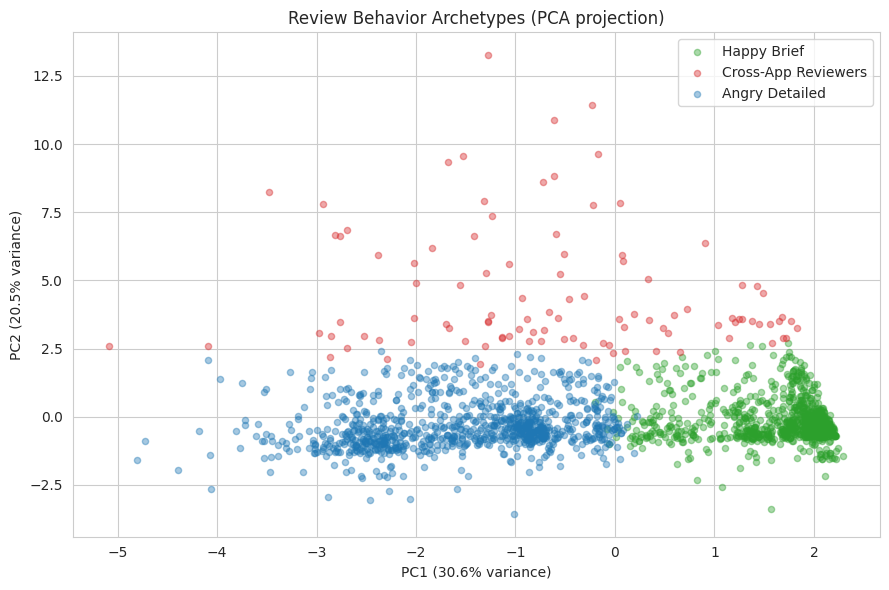

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 6))
archetype_colors = {
    'Happy Brief': '#2ca02c',
    'Cross-App Reviewers': '#d62728',
    'Angry Detailed': '#1f77b4'
}
for archetype, color in archetype_colors.items():
    mask = groups['archetype'] == archetype
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=20, alpha=0.4, color=color, label=archetype)

ax.set_title('Review Behavior Archetypes (PCA projection)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend()
plt.tight_layout()
plt.show()

## 6.4 Archetype Interpretation

The three clusters reveal distinct review behaviors at the data level:

- **Happy Brief** (~47%): high score, short reviews. A pattern of quick positive feedback.
- **Angry Detailed** (~48%): low score, long reviews. A pattern of writing to complain.
- **Cross-App Reviewers** (~5%): reviews across many apps with high score variance. A pattern of comparative reviewing.

These describe **review behavior patterns**, not identifications of individual users. The ~50/50 Happy/Angry split echoes the bimodal score distribution from 5.1, suggesting the review pool is dominated by extremes of satisfaction.